In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv('C:\\Users\\joel4\\Documents\\ecommerce-customer-analytics\\data\\online_retail_cleaned.csv')

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,years,months,YearMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,2010-12


Total Revenue

In [4]:
df['Revenue'].sum()

np.float64(8911407.904)

Total Customers

In [5]:
df['CustomerID'].nunique()

4338

Total Orders

In [6]:
df['InvoiceNo'].nunique()

18532

Average Order Value

In [7]:
df.groupby('InvoiceNo')['Revenue'].sum().mean()

np.float64(480.8659563997409)

Revenue Over Time

Group by Month

In [8]:
monthly_revenue = df.groupby('YearMonth')['Revenue'].sum().reset_index()

In [9]:
monthly_revenue['YearMonth'] = monthly_revenue['YearMonth'].astype(str)

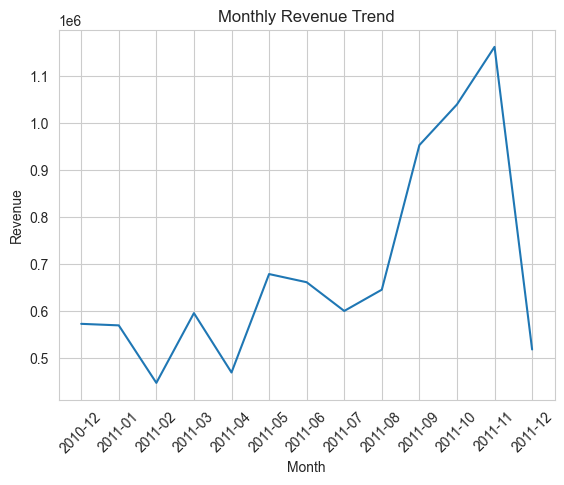

In [10]:
plt.Figure(figsize=(12, 6))
plt.plot(monthly_revenue['YearMonth'], monthly_revenue['Revenue'])
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

Top Products by Revenue

In [14]:
top_products = (df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10))


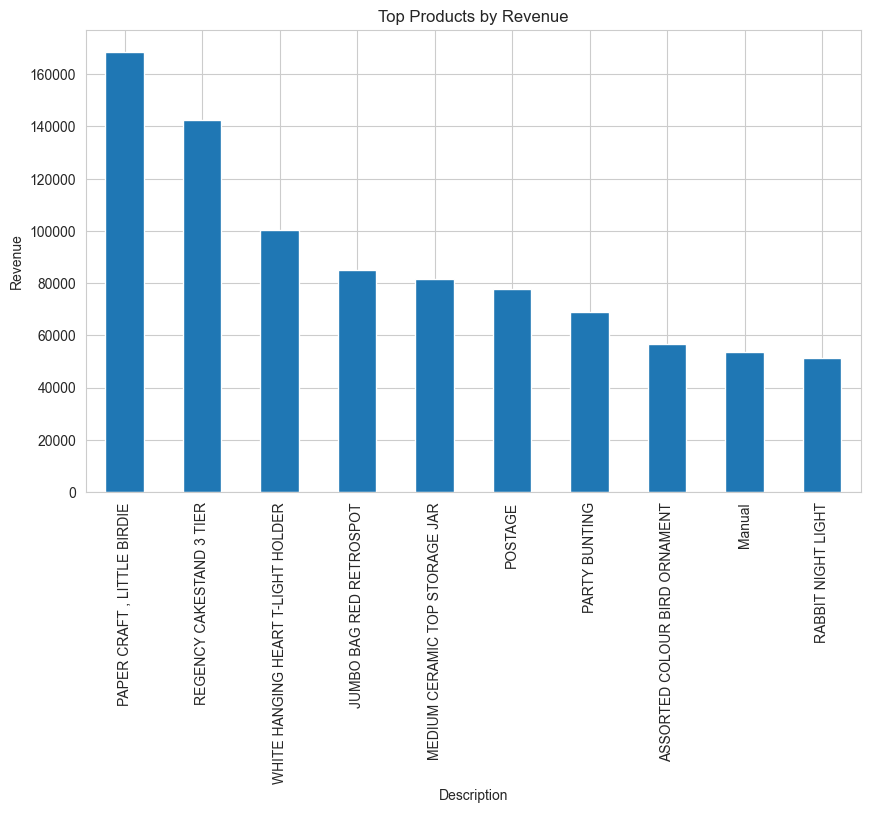

In [17]:
plt.figure(figsize=(10, 6))
top_products.plot(kind='bar')
plt.title("Top Products by Revenue")
plt.ylabel("Revenue")
plt.show()

Top Countries by Revenue

In [16]:
country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

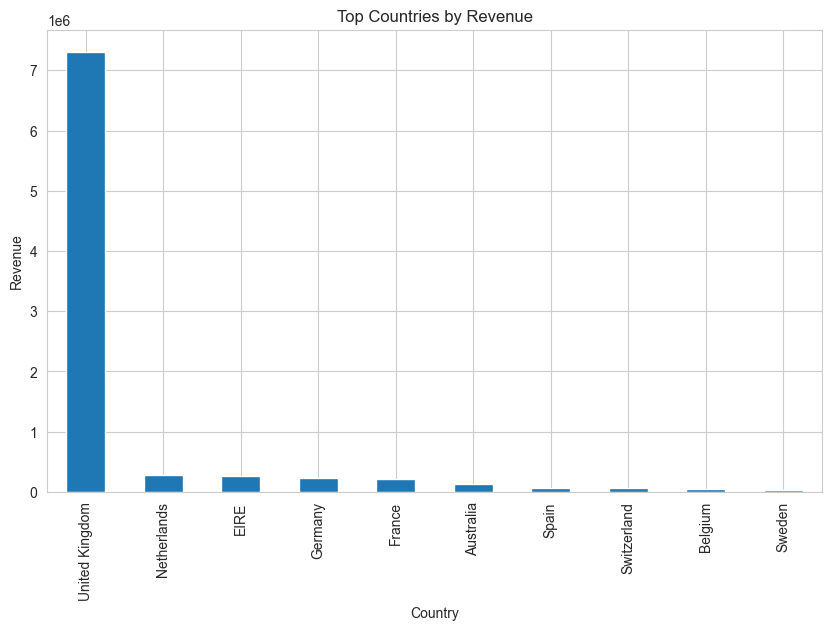

In [18]:
plt.figure(figsize=(10, 6))
country_revenue.plot(kind='bar')
plt.title("Top Countries by Revenue")
plt.ylabel("Revenue")
plt.show()

Customer Spending Distribution

In [19]:
customer_spending = df.groupby('CustomerID')['Revenue'].sum()


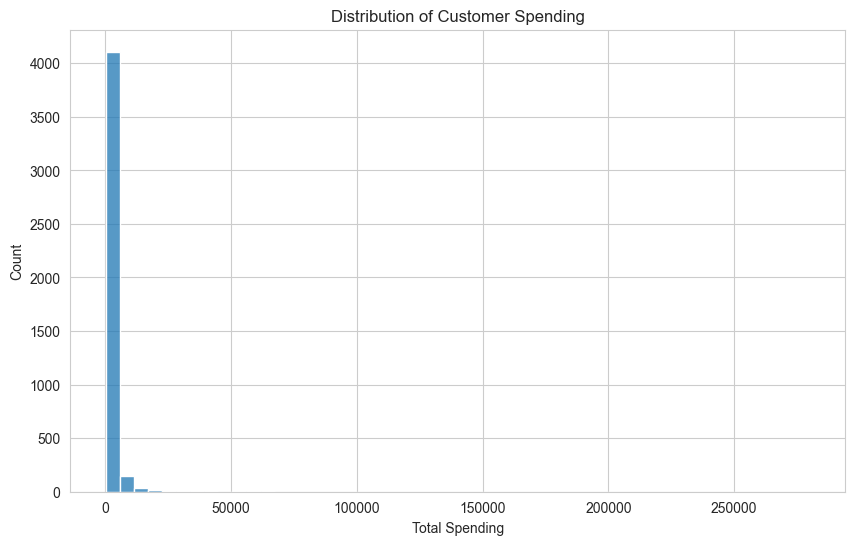

In [20]:
plt.figure(figsize=(10, 6))
sns.histplot(customer_spending, bins=50)
plt.title("Distribution of Customer Spending")
plt.xlabel("Total Spending")
plt.show()

Orders per Customer

In [21]:
orders_per_customer = df.groupby('CustomerID')['InvoiceNo'].nunique()

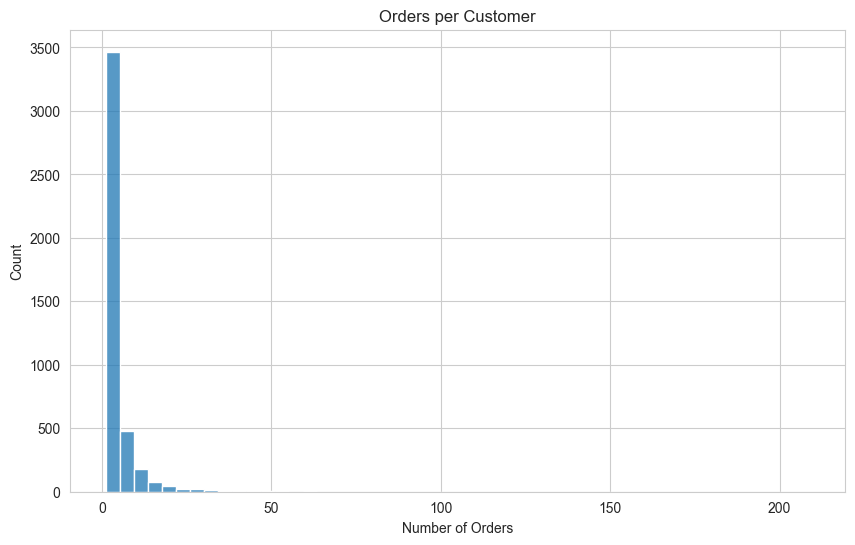

In [23]:
plt.figure(figsize=(10, 6))
sns.histplot(orders_per_customer, bins=50)
plt.title("Orders per Customer")
plt.xlabel("Number of Orders")
plt.show()